In [1]:
using Plots
using Random

CITIES = [
    565.0 575.0;  25.0 185.0; 345.0 750.0; 945.0 685.0; 845.0 655.0;
    880.0 660.0;  25.0 230.0; 525.0 1000.0; 580.0 1175.0; 650.0 1130.0;
    1605.0 620.0; 1220.0 580.0; 1465.0 200.0; 1530.0 5.0; 845.0 680.0;
    725.0 370.0; 145.0 665.0; 415.0 635.0; 510.0 875.0; 560.0 365.0;
    300.0 465.0; 520.0 585.0; 480.0 415.0; 835.0 625.0; 975.0 580.0;
    1215.0 245.0; 1320.0 315.0; 1250.0 400.0; 660.0 180.0; 410.0 250.0;
    420.0 555.0; 575.0 665.0; 1150.0 1160.0; 700.0 580.0; 685.0 595.0;
    685.0 610.0; 770.0 610.0; 795.0 645.0; 720.0 635.0; 760.0 650.0;
    475.0 960.0; 95.0 260.0; 875.0 920.0; 700.0 500.0; 555.0 815.0;
    830.0 485.0; 1170.0 65.0; 830.0 610.0; 605.0 625.0; 595.0 360.0;
    1340.0 725.0; 1740.0 245.0
]
OPT_DIST = 7542
N_CITIES = size(CITIES, 1)

function compute_dist_matrix(cities)
    n = size(cities, 1); D = zeros(Int, n, n)
    for i in 1:n, j in 1:n
        dx = cities[i,1]-cities[j,1]; dy = cities[i,2]-cities[j,2]
        D[i,j] = round(Int, sqrt(dx^2+dy^2))
    end; return D
end
DIST = compute_dist_matrix(CITIES)

function tour_length(tour, D)
    s = 0; n = length(tour)
    for i in 1:n; s += D[tour[i], tour[(i%n)+1]]; end; return s
end

function roulette_select(w)
    r = rand()*sum(w); cs = 0.0
    for i in eachindex(w); cs += w[i]; cs >= r && return i; end
    return length(w)
end

function build_tour(τ, α, β, D; q0=0.0)
    n = size(τ,1); start = rand(1:n)
    visited = falses(n); visited[start] = true
    tour = Vector{Int}(undef, n); tour[1] = start
    cands = Int[]; ws = Float64[]
    for step in 2:n
        cur = tour[step-1]; empty!(cands); empty!(ws)
        for j in 1:n
            !visited[j] || continue
            push!(cands, j); push!(ws, (τ[cur,j]^α)*((1.0/D[cur,j])^β))
        end
        next = (q0>0 && rand()<q0) ? cands[argmax(ws)] : cands[roulette_select(ws)]
        tour[step] = next; visited[next] = true
    end; return tour
end

function run_aco_animated(; n_ants=52, α=1.0, β=5.0, ρ=0.5, Q=100.0, τ0=1e-6,
                           n_gen=60, elitism=0, M_dep=0, τ_min=-1.0, τ_max=-1.0,
                           ϕ=0.0, q0=0.0, seed=42)
    Random.seed!(seed)
    n = N_CITIES; D = DIST; τ = fill(τ0, n, n)
    gb_tour = collect(1:n); gb_dist = typemax(Int)
    frame_tours = Vector{Int}[]
    frame_dists = Int[]
    hist_best = Int[]
    hist_avg  = Float64[]

    for gen in 1:n_gen
        tours = [build_tour(τ, α, β, D; q0=q0) for _ in 1:n_ants]
        if ϕ > 0
            for t in tours, s in 1:n
                a, b = t[s], t[(s%n)+1]
                τ[a,b] = (1-ϕ)*τ[a,b] + ϕ*τ0; τ[b,a] = (1-ϕ)*τ[b,a] + ϕ*τ0
            end
        end
        lengths = [tour_length(t, D) for t in tours]
        order = sortperm(lengths)
        if lengths[order[1]] < gb_dist
            gb_dist = lengths[order[1]]; gb_tour = copy(tours[order[1]])
        end
        push!(frame_tours, copy(gb_tour)); push!(frame_dists, gb_dist)
        push!(hist_best, gb_dist); push!(hist_avg, sum(lengths)/n_ants)
        τ .*= (1-ρ)
        deps = M_dep > 0 ? order[1:min(M_dep,n_ants)] : collect(1:n_ants)
        for k in deps
            Δ = Q/lengths[k]; t = tours[k]
            for s in 1:n; a,b = t[s],t[(s%n)+1]; τ[a,b] += Δ; τ[b,a] += Δ; end
        end
        if elitism > 0
            for e in 1:min(elitism,n_ants)
                k = order[e]; Δ = Q/lengths[k]; t = tours[k]
                for s in 1:n; a,b = t[s],t[(s%n)+1]; τ[a,b] += Δ; τ[b,a] += Δ; end
            end
        end
        if τ_min >= 0; clamp!(τ, τ_min, τ_max); end
    end
    return frame_tours, frame_dists, hist_best, hist_avg
end

function make_gif(name, color; kwargs...)
    println("  ▸ Генерация GIF для $name...")
    frames, dists, hist_best, _ = run_aco_animated(; kwargs...)

    anim = @animate for gen in 1:length(frames)
        tour = frames[gen]
        xs = [CITIES[tour,1]; CITIES[tour[1],1]]
        ys = [CITIES[tour,2]; CITIES[tour[1],2]]

        l = @layout [a{0.55w} b]

        p1 = plot(xs, ys; linewidth=1.5, linecolor=color, linealpha=0.85,
            label=nothing, title="$name · поколение $gen · L=$(dists[gen])",
            titlefontsize=10, aspect_ratio=:equal, grid=false, framestyle=:box,
            xticks=[], yticks=[], xlims=(-50,1850), ylims=(-100,1300))
        scatter!(p1, CITIES[:,1], CITIES[:,2];
            markersize=3, markercolor=color, markeralpha=0.7,
            markerstrokewidth=0, label=nothing)

        p2 = plot(1:gen, hist_best[1:gen];
            linewidth=2, linecolor=color, label="Лучший",
            xlabel="Поколение", ylabel="Расстояние",
            title="Схождение", titlefontsize=9,
            xlims=(0, length(frames)+1),
            ylims=(OPT_DIST*0.95, hist_best[1]*1.05),
            grid=true, gridstyle=:dot, gridalpha=0.3)
        hline!(p2, [OPT_DIST]; label="Опт. ($OPT_DIST)",
            linecolor=:red, linestyle=:dash, linewidth=1.5)

        plot(p1, p2; layout=l, size=(1000, 450), margin=4Plots.mm)
    end

    mkpath("lab16")
    path = "lab16/aco_$(replace(lowercase(name), " "=>"_")).gif"
    gif(anim, path; fps=4)
    println("    ✓ $path")
end

function main()
    mkpath("lab16")
    println("="^50)
    println("  Генерация GIF-анимаций ACO на Berlin52")
    println("="^50)

    # AS
    make_gif("AS", :dodgerblue)
    # Elitist AS
    make_gif("Elitist AS", :orangered; elitism=2)
    # MMAS: только лучшие 4 наносят, clamp τ
    make_gif("MMAS", :seagreen; M_dep=4, τ_min=1e-8, τ_max=10.0)
    # ACS: локальный распад + жадный выбор + 1 вноситель
    make_gif("ACS", :mediumpurple; M_dep=1, ϕ=0.1, q0=0.9)

    println("\n  Все GIF сохранены в lab16/\n")
end

main()

  Генерация GIF-анимаций ACO на Berlin52
  ▸ Генерация GIF для AS...
    ✓ lab16/aco_as.gif
  ▸ Генерация GIF для Elitist AS...


[ Info: Saved animation to c:\programming\optimization-methods\lab16\aco_as.gif


    ✓ lab16/aco_elitist_as.gif
  ▸ Генерация GIF для MMAS...


[ Info: Saved animation to c:\programming\optimization-methods\lab16\aco_elitist_as.gif


    ✓ lab16/aco_mmas.gif
  ▸ Генерация GIF для ACS...


[ Info: Saved animation to c:\programming\optimization-methods\lab16\aco_mmas.gif


    ✓ lab16/aco_acs.gif

  Все GIF сохранены в lab16/



[ Info: Saved animation to c:\programming\optimization-methods\lab16\aco_acs.gif


  1/4  N (число муравьёв)...


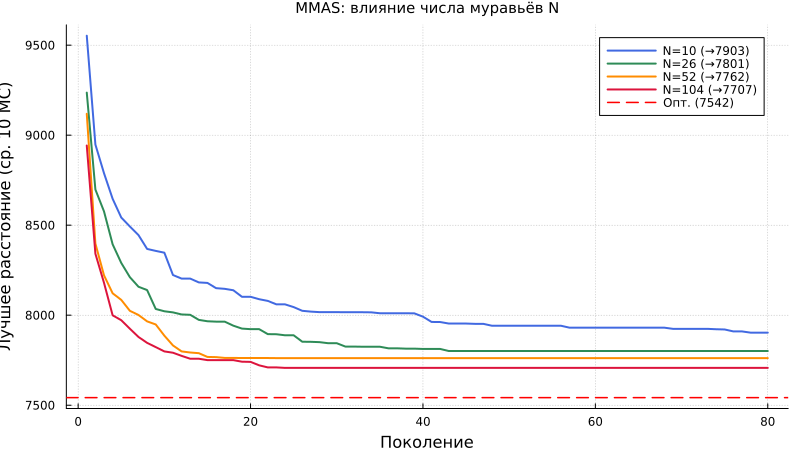

    ✓ study_n_ants.png
  2/4  ρ (испарение)...


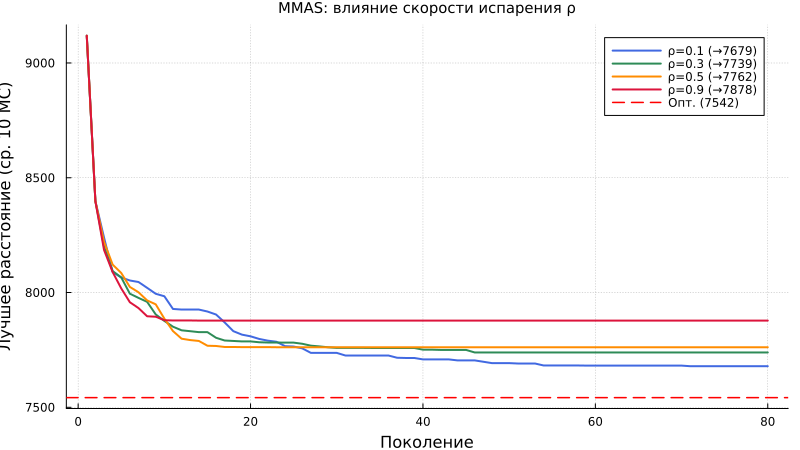

    ✓ study_rho.png
  3/4  β (вес эвристики)...


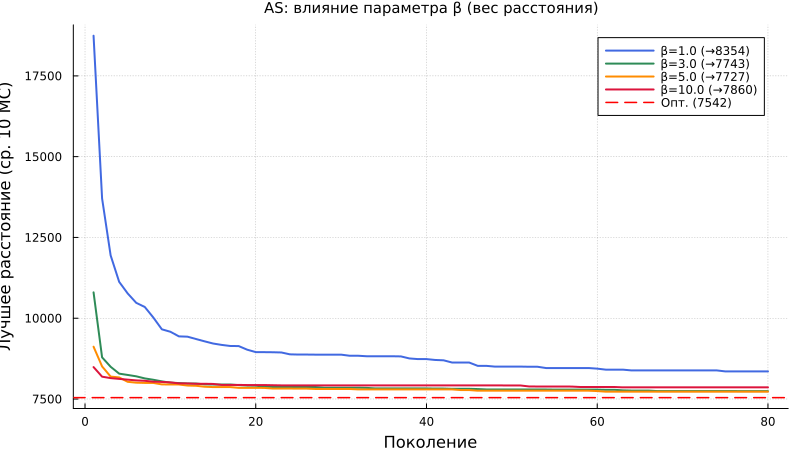

    ✓ study_beta.png
  4/4  Сравнение 4 алгоритмов...


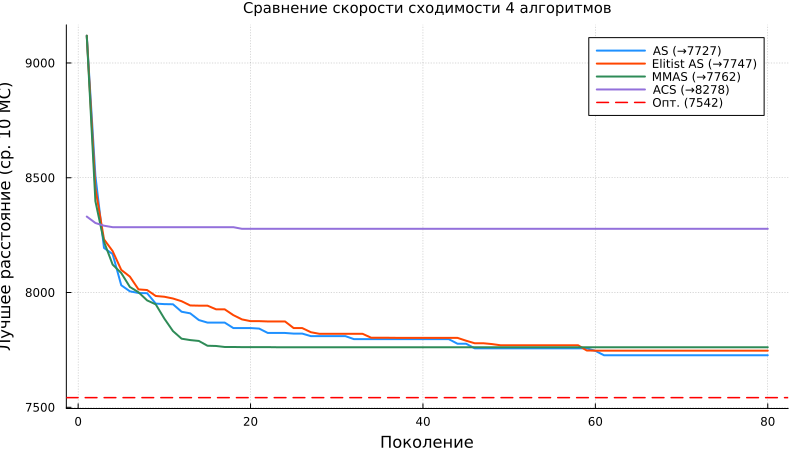

    ✓ study_algo_comparison.png


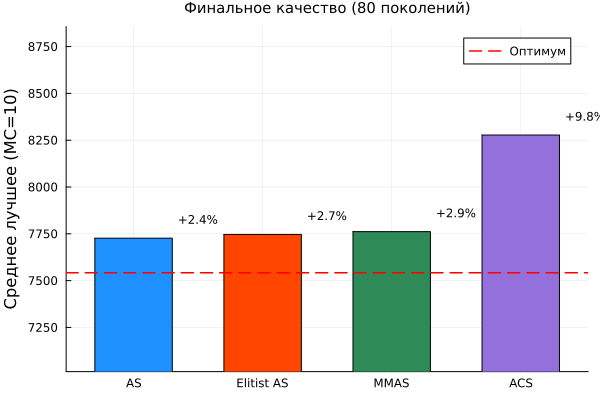

    ✓ study_final_bar.png


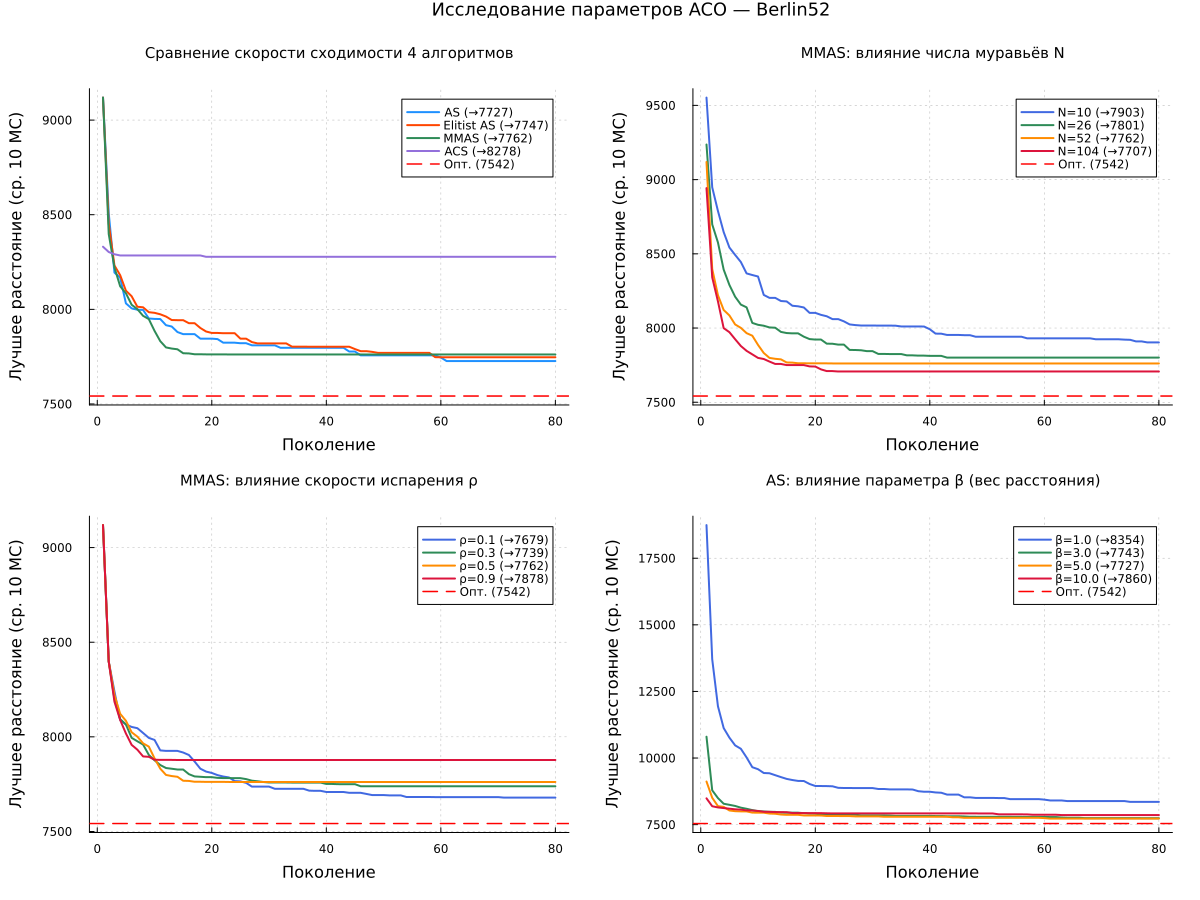

    ✓ study_dashboard.png
  Готово!



In [ ]:
using Plots, Random
gr()

# Данные (если уже определены в другой ячейке — можно убрать этот блок)
if !@isdefined(CITIES_S)
    global CITIES_S = [
        565.0 575.0;  25.0 185.0; 345.0 750.0; 945.0 685.0; 845.0 655.0;
        880.0 660.0;  25.0 230.0; 525.0 1000.0; 580.0 1175.0; 650.0 1130.0;
        1605.0 620.0; 1220.0 580.0; 1465.0 200.0; 1530.0 5.0; 845.0 680.0;
        725.0 370.0; 145.0 665.0; 415.0 635.0; 510.0 875.0; 560.0 365.0;
        300.0 465.0; 520.0 585.0; 480.0 415.0; 835.0 625.0; 975.0 580.0;
        1215.0 245.0; 1320.0 315.0; 1250.0 400.0; 660.0 180.0; 410.0 250.0;
        420.0 555.0; 575.0 665.0; 1150.0 1160.0; 700.0 580.0; 685.0 595.0;
        685.0 610.0; 770.0 610.0; 795.0 645.0; 720.0 635.0; 760.0 650.0;
        475.0 960.0; 95.0 260.0; 875.0 920.0; 700.0 500.0; 555.0 815.0;
        830.0 485.0; 1170.0 65.0; 830.0 610.0; 605.0 625.0; 595.0 360.0;
        1340.0 725.0; 1740.0 245.0
    ]
    global OPT_S = 7542
    global N_S = size(CITIES_S, 1)
    function _dm(c)
        n=size(c,1); D=zeros(Int,n,n)
        for i in 1:n, j in 1:n
            D[i,j]=round(Int,sqrt((c[i,1]-c[j,1])^2+(c[i,2]-c[j,2])^2))
        end; D
    end
    global DS = _dm(CITIES_S)
end

function _tl_s(tour,D)
    s=0; n=length(tour)
    for i in 1:n; s+=D[tour[i],tour[(i%n)+1]]; end; s
end

function _rs_s(w)
    r=rand()*sum(w); cs=0.0
    for i in eachindex(w); cs+=w[i]; cs>=r && return i; end; length(w)
end

function _bt_s(τ,α,β,D;q0=0.0)
    n=size(τ,1); st=rand(1:n); vis=falses(n); vis[st]=true
    tour=Vector{Int}(undef,n); tour[1]=st; cd=Int[]; ws=Float64[]
    for step in 2:n
        cur=tour[step-1]; empty!(cd); empty!(ws)
        for j in 1:n; !vis[j]||continue; push!(cd,j)
            push!(ws,(τ[cur,j]^α)*((1.0/D[cur,j])^β)); end
        nx=(q0>0&&rand()<q0) ? cd[argmax(ws)] : cd[_rs_s(ws)]
        tour[step]=nx; vis[nx]=true
    end; tour
end

function run_study(;n_ants=52,α=1.0,β=5.0,ρ=0.5,Q=100.0,τ0=1e-6,n_gen=80,
                    elitism=0,M_dep=0,τ_min=-1.0,τ_max=-1.0,ϕ=0.0,q0=0.0,seed=-1)
    seed>=0 && Random.seed!(seed)
    n=N_S; D=DS; τ=fill(τ0,n,n)
    gbd=typemax(Int); hb=Int[]
    for gen in 1:n_gen
        tours=[_bt_s(τ,α,β,D;q0=q0) for _ in 1:n_ants]
        if ϕ>0; for t in tours,s in 1:n; a,b=t[s],t[(s%n)+1]
            τ[a,b]=(1-ϕ)*τ[a,b]+ϕ*τ0; τ[b,a]=(1-ϕ)*τ[b,a]+ϕ*τ0; end; end
        ls=[_tl_s(t,D) for t in tours]; ord=sortperm(ls)
        if ls[ord[1]]<gbd; gbd=ls[ord[1]]; end
        push!(hb,gbd)
        τ.*=(1-ρ)
        deps=M_dep>0 ? ord[1:min(M_dep,n_ants)] : collect(1:n_ants)
        for k in deps; Δ=Q/ls[k]; t=tours[k]
            for s in 1:n; a,b=t[s],t[(s%n)+1]; τ[a,b]+=Δ; τ[b,a]+=Δ; end; end
        if elitism>0; for e in 1:min(elitism,n_ants); k=ord[e]; Δ=Q/ls[k]; t=tours[k]
            for s in 1:n; a,b=t[s],t[(s%n)+1]; τ[a,b]+=Δ; τ[b,a]+=Δ; end; end; end
        if τ_min>=0; clamp!(τ,τ_min,τ_max); end
    end; hb
end
function mc_run(n_mc; kwargs...)
    all_hb = [run_study(; seed=s, kwargs...) for s in 1:n_mc]
    ng = length(all_hb[1])
    [sum(all_hb[r][g] for r in 1:n_mc)/n_mc for g in 1:ng]
end
mkpath("lab16")
N_MC = 10; N_GEN = 80
# 1. Число муравьёв N (MMAS)
println("  1/4  N (число муравьёв)...")
p_ants = plot(; xlabel="Поколение", ylabel="Лучшее расстояние (ср. $N_MC MC)",
    title="MMAS: влияние числа муравьёв N", titlefontsize=10,
    legend=:topright, grid=true, gridstyle=:dot, gridalpha=0.3, size=(800,450))

for (na,col) in [(10,:royalblue),(26,:seagreen),(52,:darkorange),(104,:crimson)]
    hb = mc_run(N_MC; n_ants=na, n_gen=N_GEN, M_dep=4, τ_min=1e-8, τ_max=10.0)
    plot!(p_ants, 1:N_GEN, hb; lw=2, lc=col, label="N=$na (→$(round(Int,hb[end])))")
end
hline!(p_ants, [OPT_S]; lc=:red, ls=:dash, lw=1.5, label="Опт. ($OPT_S)")
display(p_ants); savefig(p_ants, "lab16/study_n_ants.png")
println("    ✓ study_n_ants.png")

# 2. Скорость испарения ρ (MMAS)
println("  2/4  ρ (испарение)...")
p_rho = plot(; xlabel="Поколение", ylabel="Лучшее расстояние (ср. $N_MC MC)",
    title="MMAS: влияние скорости испарения ρ", titlefontsize=10,
    legend=:topright, grid=true, gridstyle=:dot, gridalpha=0.3, size=(800,450))
for (rv,col) in [(0.1,:royalblue),(0.3,:seagreen),(0.5,:darkorange),(0.9,:crimson)]
    hb = mc_run(N_MC; n_ants=52, ρ=rv, n_gen=N_GEN, M_dep=4, τ_min=1e-8, τ_max=10.0)
    plot!(p_rho, 1:N_GEN, hb; lw=2, lc=col, label="ρ=$rv (→$(round(Int,hb[end])))")
end
hline!(p_rho, [OPT_S]; lc=:red, ls=:dash, lw=1.5, label="Опт. ($OPT_S)")
display(p_rho); savefig(p_rho, "lab16/study_rho.png")
println("    ✓ study_rho.png")
# 3. Вес эвристики β (AS)
println("  3/4  β (вес эвристики)...")
p_beta = plot(; xlabel="Поколение", ylabel="Лучшее расстояние (ср. $N_MC MC)",
    title="AS: влияние параметра β (вес расстояния)", titlefontsize=10,
    legend=:topright, grid=true, gridstyle=:dot, gridalpha=0.3, size=(800,450))
for (bv,col) in [(1.0,:royalblue),(3.0,:seagreen),(5.0,:darkorange),(10.0,:crimson)]
    hb = mc_run(N_MC; n_ants=52, β=bv, n_gen=N_GEN)
    plot!(p_beta, 1:N_GEN, hb; lw=2, lc=col, label="β=$bv (→$(round(Int,hb[end])))")
end
hline!(p_beta, [OPT_S]; lc=:red, ls=:dash, lw=1.5, label="Опт. ($OPT_S)")
display(p_beta); savefig(p_beta, "lab16/study_beta.png")
println("    ✓ study_beta.png")
# 4. Сравнение 4 алгоритмов (MC-усреднение)
println("  4/4  Сравнение 4 алгоритмов...")
algo_cfgs = [
    ("AS",         :dodgerblue,   Dict()),
    ("Elitist AS", :orangered,    Dict(:elitism=>2)),
    ("MMAS",       :seagreen,     Dict(:M_dep=>4, :τ_min=>1e-8, :τ_max=>10.0)),
    ("ACS",        :mediumpurple, Dict(:M_dep=>1, :ϕ=>0.1, :q0=>0.9)),
]
p_cmp = plot(; xlabel="Поколение", ylabel="Лучшее расстояние (ср. $N_MC MC)",
    title="Сравнение скорости сходимости 4 алгоритмов", titlefontsize=10,
    legend=:topright, grid=true, gridstyle=:dot, gridalpha=0.3, size=(800,450))
final_res = Dict{String,Float64}()
for (nm,col,kw) in algo_cfgs
    hb = mc_run(N_MC; n_ants=52, n_gen=N_GEN, kw...)
    final_res[nm] = hb[end]
    plot!(p_cmp, 1:N_GEN, hb; lw=2, lc=col, label="$nm (→$(round(Int,hb[end])))")
end
hline!(p_cmp, [OPT_S]; lc=:red, ls=:dash, lw=1.5, label="Опт. ($OPT_S)")
display(p_cmp); savefig(p_cmp, "lab16/study_algo_comparison.png")
println("    ✓ study_algo_comparison.png")
nms = [c[1] for c in algo_cfgs]
vals = [final_res[n] for n in nms]
cols = [c[2] for c in algo_cfgs]
gaps = [(v-OPT_S)/OPT_S*100 for v in vals]
p_bar = bar(nms, vals; color=cols, label=nothing, bar_width=0.6,
    ylabel="Среднее лучшее (MC=$N_MC)", title="Финальное качество ($N_GEN поколений)",
    titlefontsize=10, ylims=(OPT_S*0.93, maximum(vals)*1.07), size=(600,400))
hline!(p_bar, [OPT_S]; lc=:red, ls=:dash, lw=1.5, label="Оптимум")
for (i,(v,g)) in enumerate(zip(vals,gaps))
    annotate!(p_bar, i, v+100, Plots.text("+$(round(g;digits=1))%", 8, :center))
end
display(p_bar); savefig(p_bar, "lab16/study_final_bar.png")
println("    ✓ study_final_bar.png")
p_dash = plot(p_cmp, p_ants, p_rho, p_beta;
    layout=(2,2), size=(1200,900),
    plot_title="Исследование параметров ACO — Berlin52",
    plot_titlefontsize=12, margin=5Plots.mm)
display(p_dash); savefig(p_dash, "lab16/study_dashboard.png")
println("    ✓ study_dashboard.png\n  Готово!\n")